# Chapter 15. 한국어 BERT Binary — NSMC

**목표**: Phase 1 의 영어 DistilBERT 셋업을 *한국어 BERT* 로 옮깁니다. 모델 본체는 `klue/bert-base`, 데이터는 NSMC (네이버 영화 리뷰), task 와 loss 셋업은 Ch 11 과 *완전히 동일* — softmax + CrossEntropyLoss. 변하는 축은 **언어 + 토크나이저 + 데이터** 한 묶음.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 12분 (모델 다운로드 ~30s + 2 에폭 학습 ~10분 + 평가/시각화)

---

## 학습 흐름

1. 🔤 **토크나이저 비교**: 영어 WordPiece (`distilbert-base-uncased`) vs 한국어 WordPiece (`klue/bert-base`). 같은 한국어 문장이 양쪽에서 어떻게 *완전히 다르게* 쪼개지는지 직접 확인.
2. 🚀 **실습**: NSMC 5,000건 → klue/bert-base 파인튜닝 → 영화 리뷰 긍정/부정 분류
3. 🔬 **해부**: 학습 결과 — accuracy / F1 / AUC + 확률·logit 분포 KDE (Ch 10·11 의 한국어판)
4. 🛠️ **샘플 단위 해석**: 짧은 한국어 리뷰 몇 개를 골라 모델이 어떻게 판단했는지 읽어보기

---

> 📒 **사전 학습 자료**: Ch 11 (BERT Binary 방식 B — softmax+CE). 이번 챕터는 Ch 11 셋업의 *언어 swap* 버전이라 모델·loss·코드 골격은 동일. **Phase 2 핵심 학습 포인트는 토크나이저** 입니다.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 10 | DistilBERT | WordPiece (영어) | Yelp 이진화 | `Linear(H, 1)` | sigmoid | `BCEWithLogitsLoss` |
| 11 | DistilBERT | WordPiece (영어) | Yelp 이진화 | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |
| **15 ← 여기 (Phase 2 시작)** | **`klue/bert-base`** | **WordPiece (한국어)** | **NSMC (네이버 영화 리뷰)** | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |
| 16 (다음) | klue/bert-base | WordPiece (한국어) | KLUE-YNAT (뉴스 7분류) | `Linear(H, 7)` | softmax | `CrossEntropyLoss` |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

## 🔄 변경점 (Diff from Ch 11)

| 축 | Ch 11 (영어 binary) | Ch 15 (한국어 binary) |
|---|---|---|
| **언어** | 영어 | **한국어** |
| 모델 본체 | `distilbert-base-uncased` (약 66M) | **`klue/bert-base`** (110M, BERT-base full size) |
| 토크나이저 | 영어 WordPiece (vocab 30K) | **한국어 WordPiece** (vocab 32K) |
| 데이터 | Yelp 이진화 (5K샘플 / max_len 128) | **NSMC** 5K샘플 / max_len 128 |
| `num_labels` | 2 | 2 (그대로) |
| `problem_type` | `single_label_classification` | (그대로) |
| Activation / Loss | softmax / CE | (그대로) |
| 라벨 형식 | int 0/1 | int 0/1 (그대로) |
| 학습 hyperparams | (epoch=2, lr=2e-5, batch=16, seed=42) | (그대로) |

> **Phase 2 의 `변경점 한 가지 원칙` 변형**: 입문 수준에선 *언어 + 토크나이저 + 데이터* 가 한 묶음으로 같이 변합니다. *모델·loss·셋업이 그대로* 라 가르침은 Phase 1 과 분리해 *한국어 자체의 학습 어려움* 에만 집중할 수 있습니다.

### 왜 한국어가 영어 BERT 와 *그렇게* 다른가

영어 distilbert-base-uncased 토크나이저로 한국어를 처리하면 *처참한* 토큰화가 나옵니다. 영어 vocab 에 한국어 글자가 없어서 *바이트 단위* (`[UNK]` 또는 `##` prefix 부스러기) 로 깨집니다. 모델이 학습한 단어 임베딩이 한국어를 못 받아내요.

**해결**: *한국어 텍스트로 사전학습된* BERT 와 그 토크나이저를 사용. 이번 챕터는 KLUE 연구팀의 `klue/bert-base` — 한국어 위키 + 뉴스 + 댓글 등으로 사전학습.

## 📐 Loss 노트 — Ch 11 그대로

`CrossEntropyLoss`. 새로운 점은 없습니다 — *binary 분류 셋업* 이라 K=2, softmax 후 정답 클래스 확률에 -log.

$$L = -\frac{1}{N}\sum_{i=1}^{N}\log \hat p_{i, y_i} \quad\text{where}\quad \hat p_{i,k} = \dfrac{e^{z_{i,k}}}{e^{z_{i,0}} + e^{z_{i,1}}}$$

데이터 분포는 *NSMC 가 거의 완벽 균형* (긍정 ~50%, 부정 ~50%) 이라 random baseline loss = $\log 2 = 0.693$. 학습 첫 step 에서 loss 가 이 근처면 정상.

## 🔤 토크나이저 노트 — Phase 2 의 핵심

**Ch 11 까지는** `distilbert-base-uncased` (영어 WordPiece) 를 그대로 썼습니다. **Ch 15 부터는** `klue/bert-base` (한국어 WordPiece). 두 토크나이저가 *같은 한국어 문장* 을 어떻게 다르게 쪼개는지가 이번 챕터의 *교훈* 의 절반입니다.

### 직관 — 같은 문장, 두 토크나이저

문장: `"이 영화 정말 재미있었어요"`

| 토크나이저 | 결과 토큰 | 토큰 수 |
|---|---|---|
| `distilbert-base-uncased` (영어) | `['ᄋ', '##ᅵ', 'ᄋ', '##ᅧ', '##ᆼ', '##ᄒ', '##ᅪ', 'ᄌ', '##ᅥ', '##ᆼ', '##ᄆ', '##ᅡ', '##ᆯ', '[UNK]']` 같이 *자모(초·중·종성) 단위* 로 산산조각 (또는 [UNK] 가득) | 14 |
| `klue/bert-base` (한국어) | `['이', '영화', '정말', '재미있', '##었', '##어요']` — *의미 있는 어휘* 단위 | 6 |

영어 토크나이저는 한국어를 *낯선 문자열* 로 보고 글자 단위까지 쪼갭니다. 한국어 토크나이저는 *재미있·었·어요* 를 어휘적 의미 단위로 분할 — 모델이 임베딩을 통해 *의미* 를 잡을 수 있는 형태.

이 비교는 §실습 직전에 *코드로 직접* 확인합니다.

### 한국어 WordPiece 의 특징

- vocab 32,000 (영어 30K 와 비슷한 규모)
- *어절 단위* 가 아니라 *형태소-비슷한* 서브워드 단위. 예: "재미있었어요" → "재미있" + "##었" + "##어요" (어간 + 어미)
- 영어처럼 `##` prefix 가 *이전 토큰에 이어지는 부분* 을 표시
- 한자·숫자·영어 단어도 vocab 에 포함 (한국어 텍스트엔 흔히 섞여 있음)

### Phase 2 의 토크나이저는 *이번 챕터부터 끝까지* `klue/bert-base` 고정

Ch 16, 17, 18 도 같은 토크나이저. 변하는 건 *데이터·task* 만. 영어 → 한국어 전환은 *이 챕터에서 한 번* 일어나고, 이후엔 한국어 셋업이 표준.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import io
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, roc_auc_score,
)

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CPU runtime — training will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
GPU:             Tesla T4


**baseline VRAM**:

In [3]:
!nvidia-smi

Sun Jun 21 23:06:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 🔤 토크나이저 비교 — 같은 한국어 문장, 두 토크나이저

`klue/bert-base` (한국어) 와 `distilbert-base-uncased` (영어) 두 토크나이저로 *같은* 한국어 문장을 처리해 차이를 직접 봅니다.

In [4]:
tokenizer_ko = AutoTokenizer.from_pretrained("klue/bert-base")
tokenizer_en = AutoTokenizer.from_pretrained("distilbert-base-uncased")

samples = [
    "이 영화 정말 재미있었어요",
    "별로였어요. 시간 낭비",
    "오랜만에 본 명작이네요!",
]

for sent in samples:
    print(f"text: {sent}")
    tok_ko = tokenizer_ko.tokenize(sent)
    tok_en = tokenizer_en.tokenize(sent)
    print(f"  klue/bert-base ({len(tok_ko):>2} tokens): {tok_ko}")
    print(f"  distilbert-en  ({len(tok_en):>2} tokens): {tok_en}")
    print()

print(f"klue/bert-base vocab size:        {tokenizer_ko.vocab_size:,}")
print(f"distilbert-base-uncased vocab:    {tokenizer_en.vocab_size:,}")

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

text: 이 영화 정말 재미있었어요
  klue/bert-base ( 6 tokens): ['이', '영화', '정말', '재미있', '##었', '##어요']
  distilbert-en  (14 tokens): ['ᄋ', '##ᅵ', 'ᄋ', '##ᅧ', '##ᆼ', '##ᄒ', '##ᅪ', 'ᄌ', '##ᅥ', '##ᆼ', '##ᄆ', '##ᅡ', '##ᆯ', '[UNK]']

text: 별로였어요. 시간 낭비
  klue/bert-base ( 6 tokens): ['별로', '##였', '##어요', '.', '시간', '낭비']
  distilbert-en  (12 tokens): ['[UNK]', '.', 'ᄉ', '##ᅵ', '##ᄀ', '##ᅡ', '##ᆫ', 'ᄂ', '##ᅡ', '##ᆼ', '##ᄇ', '##ᅵ']

text: 오랜만에 본 명작이네요!
  klue/bert-base ( 8 tokens): ['오랜만', '##에', '본', '명작', '##이', '##네', '##요', '!']
  distilbert-en  (26 tokens): ['ᄋ', '##ᅩ', '##ᄅ', '##ᅢ', '##ᆫ', '##ᄆ', '##ᅡ', '##ᆫ', '##ᄋ', '##ᅦ', 'ᄇ', '##ᅩ', '##ᆫ', 'ᄆ', '##ᅧ', '##ᆼ', '##ᄌ', '##ᅡ', '##ᆨ', '##ᄋ', '##ᅵ', '##ᄂ', '##ᅦ', '##ᄋ', '##ᅭ', '!']

klue/bert-base vocab size:        32,000
distilbert-base-uncased vocab:    30,522


**관찰**

- 한국어 토크나이저는 *어휘적 의미 단위* 로 분할 — `재미있` + `##었` + `##어요` 처럼 어간·어미를 살림
- 영어 토크나이저는 한국어를 *글자 단위* 로 쪼개거나 (`이`, `영`, `##화`) `[UNK]` 로 처리 — 의미를 못 잡음
- vocab 크기는 비슷 (32K vs 30K) 지만 *내용물이 완전히 다름* — 한국어 vocab 은 한국어 빈도 어휘 32K, 영어 vocab 은 영어 빈도 어휘 30K
- 토큰 수도 한국어 토크나이저가 *훨씬 적음* — 같은 문장이라도 짧은 시퀀스로 표현되어 학습 효율도 좋음

## 2. 🚀 데이터 — NSMC (네이버 영화 리뷰)

NSMC = Naver Sentiment Movie Corpus. 한국어 *binary* 감성 분류의 표준 벤치마크. 한 줄짜리 짧은 리뷰 + 긍정(1) / 부정(0) 라벨.

**원본**: e9t/nsmc GitHub 의 `ratings_train.txt` / `ratings_test.txt` TSV. Hugging Face datasets hub 의 nsmc 레포는 *로더 스크립트* 기반이라 최신 datasets 라이브러리에서 deprecated — 그래서 GitHub raw URL 에서 직접 받습니다.

In [5]:
TRAIN_URL = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
TEST_URL  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

print("downloading NSMC train/test from GitHub...")
df_train_full = pd.read_csv(TRAIN_URL, sep="\t").dropna(subset=["document"])
df_test_full  = pd.read_csv(TEST_URL,  sep="\t").dropna(subset=["document"])
print(f"  train: {len(df_train_full):,} rows")
print(f"  test:  {len(df_test_full):,} rows")
print(f"  label distribution (train): {df_train_full['label'].value_counts().to_dict()}")
print(f"\nfirst 3 rows of train:")
for _, row in df_train_full.head(3).iterrows():
    print(f"  label={row['label']}  text={row['document'][:80]}")

downloading NSMC train/test from GitHub...


  train: 149,995 rows
  test:  49,997 rows
  label distribution (train): {0: 75170, 1: 74825}

first 3 rows of train:
  label=0  text=아 더빙.. 진짜 짜증나네요 목소리
  label=1  text=흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
  label=0  text=너무재밓었다그래서보는것을추천한다


In [6]:
# 5K train / 1K eval 로 subsample (T4 30분 룰)
SEED = 42
df_train = df_train_full.sample(n=5000, random_state=SEED).reset_index(drop=True)
df_eval  = df_test_full.sample(n=1000,  random_state=SEED).reset_index(drop=True)

print(f"sampled train: {len(df_train)}")
print(f"sampled eval:  {len(df_eval)}")
print(f"train positive rate: {df_train['label'].mean():.1%}")
print(f"eval  positive rate: {df_eval['label'].mean():.1%}")

# datasets.Dataset 형태로 변환
train_ds = Dataset.from_pandas(df_train[["document", "label"]])
eval_ds  = Dataset.from_pandas(df_eval[["document", "label"]])

# 컬럼 이름을 transformers 표준에 맞게 통일
train_ds = train_ds.rename_column("document", "text")
eval_ds  = eval_ds.rename_column("document", "text")
print()
print(train_ds)

sampled train: 5000
sampled eval:  1000
train positive rate: 49.2%
eval  positive rate: 49.9%

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


## 3. 토큰화 — Ch 11 패턴 그대로, 토크나이저만 한국어로

Ch 11 와 *한 줄 차이* — 토크나이저 인스턴스가 영어 → 한국어. 라벨 형식 `int(b)` 도 그대로.

In [7]:
tokenizer = tokenizer_ko   # klue/bert-base (위에서 로드)

def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [int(l) for l in batch["label"]]
    return out

train_tok = train_ds.map(tokenize_fn, batched=True).remove_columns(["text", "label"])
eval_tok  = eval_ds.map(tokenize_fn,  batched=True).remove_columns(["text", "label"])

print(train_tok)
print(f"\nFirst sample label: {train_tok[0]['labels']}  (int scalar 0=neg / 1=pos)")
# 토큰화된 첫 샘플의 길이
lens = [len(s) for s in train_tok["input_ids"]]
print(f"\nToken length stats — mean: {np.mean(lens):.1f}, median: {np.median(lens):.0f}, max: {max(lens)}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})

First sample label: 1  (int scalar 0=neg / 1=pos)

Token length stats — mean: 21.9, median: 17, max: 117


## 4. 모델 로드 — `klue/bert-base` + binary 분류 헤드

Ch 11 에서 `distilbert-base-uncased` 였던 자리만 `klue/bert-base` 로 교체. 분류 헤드 `Linear(H, 2)` + `single_label_classification` 셋업은 동일.

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2,
    problem_type="single_label_classification",
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1},
)

def param_summary(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total, trainable = param_summary(model)
print(f"Parameters:           {total:>13,}  ({total/1e6:.1f} M)")
print(f"Trainable parameters: {trainable:>13,}  ({trainable/total:.1%})")
print(f"Classifier:           {model.classifier}")
print(f"problem_type:         {model.config.problem_type}")
print(f"hidden size H:        {model.config.hidden_size}")
print(f"vocab size V:         {model.config.vocab_size:,}")

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters:             110,618,882  (110.6 M)
Trainable parameters:   110,618,882  (100.0%)
Classifier:           Linear(in_features=768, out_features=2, bias=True)
problem_type:         single_label_classification
hidden size H:        768
vocab size V:         32,000


**파라미터 수 비교 — Ch 11 vs Ch 15**

| | Ch 11 (`distilbert-base-uncased`) | Ch 15 (`klue/bert-base`) |
|---|---|---|
| Layer 수 | 6 | 12 (BERT-base full) |
| Hidden size H | 768 | 768 |
| 총 파라미터 | 약 67M (헤드 포함) | **110M** |

`klue/bert-base` 는 BERT-base 풀 사이즈 (12 레이어). DistilBERT 는 그 절반(6 레이어)으로 distill 한 *경량* 모델. 그래서 같은 5K 샘플 학습이 *약 1.5-2 배* 시간이 더 걸립니다.

In [9]:
!nvidia-smi

Sun Jun 21 23:06:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 5. 학습 — Ch 11 과 동일한 hyperparams

`compute_metrics` 도 binary 분류용 그대로.

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # logits.shape = (B, 2)  → softmax → 클래스 1 확률
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs_full = exp / exp.sum(axis=1, keepdims=True)
    probs = probs_full[:, 1]
    preds = probs_full.argmax(axis=1)

    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy":  float(accuracy_score(labels, preds)),
        "precision": float(p),
        "recall":    float(r),
        "f1":        float(f1),
        "auc":       float(roc_auc_score(labels, probs)),
    }

In [11]:
training_args = TrainingArguments(
    output_dir="./ch15_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(f"\nTraining done — mean train loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.386037,0.344485,0.848000,0.840864,0.857715,0.849206,0.928992
2,0.209452,0.386233,0.873000,0.879592,0.863727,0.871587,0.929092



Training done — mean train loss: 0.2997


In [12]:
!nvidia-smi

Sun Jun 21 23:07:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P0             66W /   70W |    2627MiB /  15360MiB |     85%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 6. 🔬 평가 — softmax 확률 분포

Ch 11 의 평가 패턴 그대로 — 2차원 logit 에서 softmax → 클래스 1 확률 추출, 1차원 logit z = z_1 - z_0 도 같이 만들어 시각화 호환.

In [13]:
eval_metrics = trainer.evaluate()
print("klue/bert-base NSMC binary — evaluation:")
for k, v in eval_metrics.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>20}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.209452,0.386233,2,0.873000,0.879592,0.863727,0.871587,0.929092


klue/bert-base NSMC binary — evaluation:
             eval_loss: 0.3862
         eval_accuracy: 0.8730
        eval_precision: 0.8796
           eval_recall: 0.8637
               eval_f1: 0.8716
              eval_auc: 0.9291


In [14]:
preds_output = trainer.predict(eval_tok)
logits2 = preds_output.predictions
labels  = preds_output.label_ids.astype(int)

exp = np.exp(logits2 - logits2.max(axis=1, keepdims=True))
probs_full = exp / exp.sum(axis=1, keepdims=True)
probs = probs_full[:, 1]
logits = logits2[:, 1] - logits2[:, 0]

print(f"logits2 (raw)  shape: {logits2.shape}")
print(f"logit z = z1-z0 range: [{logits.min():.2f}, {logits.max():.2f}]")
print(f"prob range:           [{probs.min():.4f}, {probs.max():.4f}]")
print(f"positive prediction rate (prob >= 0.5): {(probs >= 0.5).mean():.1%}")

logits2 (raw)  shape: (1000, 2)
logit z = z1-z0 range: [-5.53, 5.28]
prob range:           [0.0039, 0.9949]
positive prediction rate (prob >= 0.5): 49.0%


In [15]:
# 분류 리포트
print(classification_report(
    labels, probs_full.argmax(axis=1),
    target_names=["negative", "positive"],
    digits=4,
))

              precision    recall  f1-score   support

    negative     0.8667    0.8822    0.8744       501
    positive     0.8796    0.8637    0.8716       499

    accuracy                         0.8730      1000
   macro avg     0.8731    0.8730    0.8730      1000
weighted avg     0.8731    0.8730    0.8730      1000



### 6-1. 메인 그림 — 확률 공간 KDE (Ch 11 와 동일 패턴)

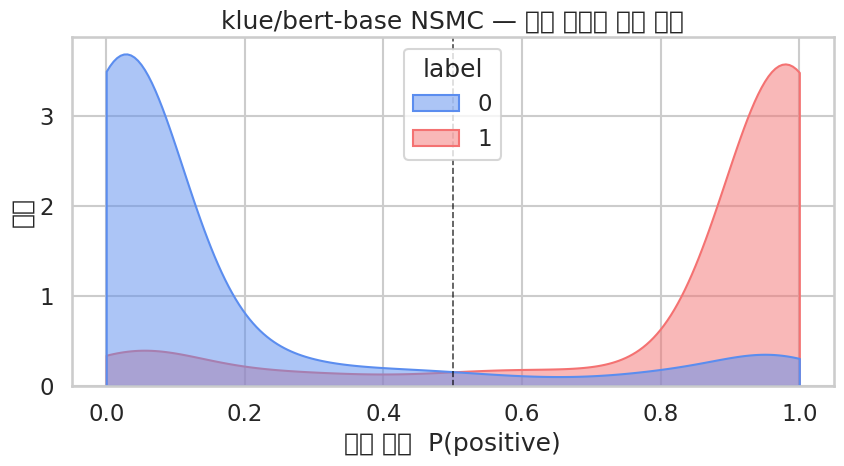

In [16]:
sns.set_theme(style="whitegrid", context="talk")
PAL = {0: "#5B8DEF", 1: "#F47272"}
df_eval = pd.DataFrame({"prob": probs, "logit": logits, "label": labels})

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(
    data=df_eval, x="prob", hue="label",
    fill=True, common_norm=False, alpha=0.5,
    palette=PAL, clip=(0, 1), ax=ax,
)
ax.axvline(0.5, color="black", lw=1.2, ls="--", alpha=0.7)
ax.set_title("klue/bert-base NSMC — 실제 라벨별 확률 분포")
ax.set_xlabel("예측 확률  P(positive)")
ax.set_ylabel("밀도")
plt.tight_layout()
plt.show()

### 6-2. 보조 그림 — logit 공간 KDE (z = z_1 - z_0)

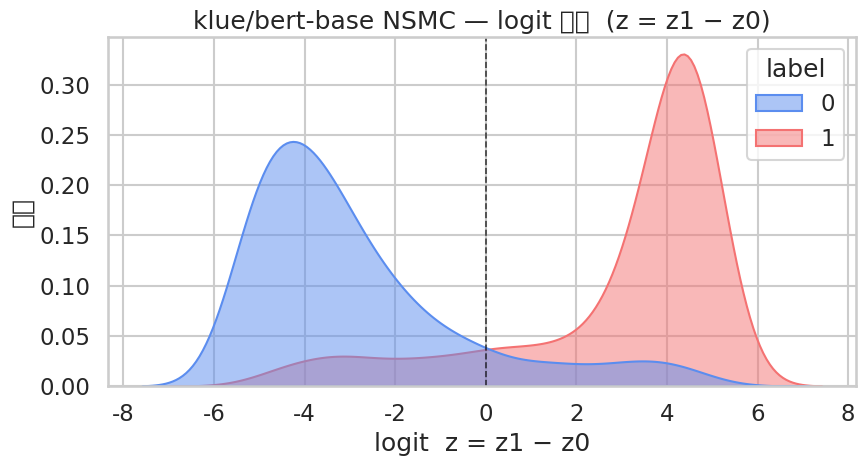

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(
    data=df_eval, x="logit", hue="label",
    fill=True, common_norm=False, alpha=0.5,
    palette=PAL, ax=ax,
)
ax.axvline(0.0, color="black", lw=1.2, ls="--", alpha=0.7)
ax.set_title("klue/bert-base NSMC — logit 분포  (z = z1 − z0)")
ax.set_xlabel("logit  z = z1 − z0")
ax.set_ylabel("밀도")
plt.tight_layout()
plt.show()

**해석**

- 두 KDE 가 잘 분리되면 모델이 한국어 감성을 학습한 것. NSMC 는 짧은 한 줄 리뷰라 정보가 적어 영어 Yelp 보다 *조금 더 어려운* 데이터.
- 보통 NSMC 5K 샘플 + 2 에폭이면 accuracy 85-88% 정도. 90%+ 가 목표면 학습 데이터를 30K 이상으로 늘려야 함.

### 6-3. 샘플 단위 해석 — 실제 한국어 리뷰가 어떻게 분류되나

평가 데이터에서 *모델이 가장 자신 있는* 샘플과 *가장 망설이는* 샘플을 골라 직접 읽어봅니다. 짧은 한국어 리뷰가 모델 입장에서 어떻게 보이는지 감을 잡습니다.

In [18]:
# 가장 자신있게 positive (probs 최대), 가장 자신있게 negative (probs 최소),
# 가장 망설이는 (|probs - 0.5| 최소) 3가지 샘플
texts = list(df_eval.assign(text=eval_ds["text"])["text"]) if "text" in eval_ds.column_names else list(eval_ds["text"])

# eval_tok 와 eval_ds 의 순서가 같으므로 인덱스 직접 사용
idx_top_pos    = int(np.argmax(probs))
idx_top_neg    = int(np.argmin(probs))
idx_uncertain  = int(np.argmin(np.abs(probs - 0.5)))

samples = [
    ("most confident positive", idx_top_pos),
    ("most confident negative", idx_top_neg),
    ("most uncertain (prob ≈ 0.5)", idx_uncertain),
]

for label_str, idx in samples:
    print("=" * 78)
    print(f"sample #{idx}  ({label_str})")
    print("=" * 78)
    print(f"text:        {texts[idx]}")
    print(f"true label:  {labels[idx]}  ({'positive' if labels[idx] == 1 else 'negative'})")
    print(f"prob(pos):   {probs[idx]:.4f}")
    print(f"logit z:     {logits[idx]:+.2f}")
    pred_label = int(probs[idx] >= 0.5)
    pred_str = "positive" if pred_label == 1 else "negative"
    match = "✓" if pred_label == labels[idx] else "✗"
    print(f"prediction:  {pred_label} ({pred_str})    match: {match}")
    print()

sample #580  (most confident positive)
text:        아 최고.. 지금 수능 끝나고 보고 있어요ㅠㅠ 현실적인 30대의 사랑이야기~
true label:  1  (positive)
prob(pos):   0.9949
logit z:     +5.28
prediction:  1 (positive)    match: ✓

sample #834  (most confident negative)
text:        진자 재미없어..ㅋㅋ 액션은 볼만한데 CG안습
true label:  0  (negative)
prob(pos):   0.0039
logit z:     -5.53
prediction:  0 (negative)    match: ✓

sample #110  (most uncertain (prob ≈ 0.5))
text:        제목이 데스노튼데 데스노트가 안나온다고 뭐라 하는건 좀 그래보인다.난 차라리 원작이랑 억지스럽게 엮지않고 L의 이야기만 풀어간게 오히려 더 좋았어.
true label:  1  (positive)
prob(pos):   0.5035
logit z:     +0.01
prediction:  1 (positive)    match: ✓



**관찰 포인트**

- *가장 자신있는* 샘플들은 보통 *명확한 감성 표현* 이 들어 있음 (`"인생 영화"`, `"시간 아까움"` 같은). 모델이 그런 시그널 단어 + 문맥을 잘 잡았다는 신호.
- *망설이는 샘플 (prob ≈ 0.5)* 은 *모호하거나 짧거나 반어* 인 경우. NSMC 에는 `"음..."`, `"글쎄요"` 같은 한 두 글자 리뷰도 있어 모델 입장에선 정보 부족.
- 자신 있는 *오답* (틀렸는데 prob 가 0.9+) 이면 *반어법* (`"이게 영화냐 ㅎㅎ"` 형태) 이거나 라벨 노이즈. NSMC 에 라벨 오류가 ~3-5% 있다고 알려져 있음.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `AutoTokenizer.from_pretrained("klue/bert-base")` | 한국어 BERT-base 토크나이저 (vocab 32K) | Ch 16-18 모두 같은 토크나이저 |
| `AutoModelForSequenceClassification.from_pretrained("klue/bert-base", ...)` | 한국어 BERT-base + 분류 헤드 | Ch 16-18 모델 본체 |
| `pandas.read_csv(URL, sep="\t")` | GitHub raw TSV 직접 다운로드 | NSMC 외에도 자주 쓰는 패턴 |
| `Dataset.from_pandas(df)` | pandas DataFrame → datasets.Dataset 변환 | 외부 데이터를 transformers 파이프라인에 연결 |

## 🎯 체크포인트 질문

1. 같은 한국어 문장을 영어 토크나이저 (`distilbert-base-uncased`) 와 한국어 토크나이저 (`klue/bert-base`) 로 토큰화한 결과가 왜 *그렇게* 다른가요? vocab 의 어떤 차이가 핵심인가요?
2. NSMC 가 영어 Yelp 와 비교해 *왜 더 어려운* 데이터인지 두 가지만 들어보세요.
3. `klue/bert-base` 의 파라미터 수가 110M, DistilBERT 가 67M 인데 정확도 차이가 *극적이지 않은* 이유는?
4. Ch 11 과 Ch 15 사이에 *셋업 코드 자체* 가 거의 똑같은데도 챕터를 분리한 이유는?

## ❓ FAQ

### Q1. (실무) 한국어 BERT 모델로 `klue/bert-base` 외에 어떤 선택지가 있나요?

**기본 (입문)**:
- `klue/bert-base` (110M) — 이번 챕터. KLUE 벤치마크와 함께 공개, 한국어 표준.
- `klue/roberta-base` (110M) — RoBERTa 변형, NSP 없이 학습. 보통 KLUE 벤치마크에서 BERT 보다 약간 좋음.

**경량화 (속도/메모리)**:
- `monologg/kobert` (90M) — 초기 한국어 BERT, 입력 vocab 이 작음.
- `monologg/distilkobert` (~28M) — DistilBERT 한국어 버전. 로컬 inference 빠름.

**대형 (정확도)**:
- `klue/roberta-large` (340M) — 메모리·시간 충분하면.
- `kykim/bert-kor-base` (110M) — 다른 사전학습 코퍼스 (대화체에 강함).

**선택 기준**:
- *입문/실험*: klue/bert-base
- *프로덕션 + 속도*: distilkobert
- *최고 정확도*: klue/roberta-large 또는 deberta-v3-large 한국어 변형

### Q2. (이론) 왜 한국어 BERT 가 영어 BERT 와 *같은 아키텍처* 로도 잘 동작하나요?

BERT 의 트랜스포머 인코더는 *언어 가정* 을 거의 안 합니다 — 단지 "토큰 시퀀스의 self-attention" 만. 언어별 차이는 *토크나이저 + 사전학습 데이터* 에서 발생합니다.

```
영어 BERT 와 한국어 BERT 의 차이:
  - 토크나이저 vocab → 32K (한국어) / 30K (영어)
  - 사전학습 corpus → 한국어 위키+뉴스 / 영어 위키+책
  - 모델 weight → 두 corpus 에 맞춰 업데이트 (구조는 동일)
```

같은 아키텍처가 *어떤 텍스트로 학습됐는가* 만 다릅니다. 그래서 다국어 BERT (`xlm-roberta-base`) 는 *하나의 모델* 로 100+ 언어를 처리 — 토크나이저 vocab 만 다국어로 통합.

### Q3. (실무) NSMC 외에 한국어 binary 분류로 흔히 쓰이는 데이터셋은?

| 데이터셋 | 도메인 | 라벨 | 크기 |
|---|---|---|---|
| **NSMC** (이번 챕터) | 영화 리뷰 | 긍정/부정 | 200K (15만 train, 5만 test) |
| **KOSAC** | 다양 (뉴스/리뷰/SNS) | 긍정/부정 + sentiment intensity | 7K |
| **steam-korean-review** | 게임 리뷰 | 긍정/부정 | 100K+ |
| **AI Hub 감성대화** | 대화 | 7가지 감성 (binary 변환 가능) | 70K |

**주의**: 위 데이터셋들은 라이선스가 다양 (CC-BY, MIT, AI Hub 가입 필요 등). 상업 이용 전엔 라이선스 확인 필수.

### Q4. (실무) `klue/bert-base` 가 NSMC 학습에 *왜 잘 들어맞나*?

KLUE 사전학습 코퍼스에 *한국어 영화 리뷰 + 댓글* 이 포함되어 있어 NSMC 의 *짧고 구어체* 인 문장 분포를 BERT 가 이미 익힌 상태입니다. 위키만으로 사전학습된 한국어 모델은 NSMC 같은 *비-격식* 텍스트에 약함.

도메인이 *격식체 문서* (법률·특허·논문) 면 `kpfbert/bert-base-korean-legal-news` 같은 도메인 특화 모델이 더 나을 수 있음.

### Q5. (이론) NSMC 의 *짧은 한 줄 리뷰* 가 학습에 어떤 영향을 주나요?

긍정/부정 신호가 보통 *한두 단어에 집중* 됩니다 (`"명작"`, `"시간 낭비"`, `"감동"`). BERT 입장에서 *문맥 이해* 의 의의가 줄어들고 *키워드 매칭* 에 가까워짐 — sklearn TF-IDF + LogReg 도 NSMC 에서 80% 정확도 가능.

BERT 의 진짜 강점 (긴 문맥에서 *반어*, *조건절*, *비유* 추론) 은 *긴 문서 분류* 데이터에서 더 잘 드러남. Ch 16 의 KLUE-YNAT (뉴스 7분류) 같은 task 가 이런 성격.

### Q6. (실무) 한국어 sentiment task 에서 prediction confidence 가 0.5 근처에 몰리는 샘플들은 보통 어떤 케이스?

세 가지 패턴:

1. **반어/풍자** — `"이걸 영화라고 만든 거야 ㅎㅎ"` 처럼 *문자적 의미와 반대* 의 sentiment. 모델이 표면 단어 (`영화`, `만든`) 와 부정 신호 (`ㅎㅎ` 비웃음) 사이에서 갈팡질팡.
2. **모호한 평가** — `"그냥 그랬음"`, `"볼만함"` 같은 *중립에 가까운* 표현. NSMC 라벨 자체가 binary 라 양쪽 다 가능.
3. **너무 짧음** — `"음..."`, `"글쎄"` 같은 1-2 글자 리뷰. 모델이 판단할 정보 부족.

운영 환경에선 prob ∈ [0.4, 0.6] 샘플들을 *human review* 로 보내는 패턴이 흔함 (active learning).

## 🚀 삽질 코너 (선택)

다음 코드를 돌려보면 어떤 결과가 나올까요?

```python
# 한국어 데이터를 *영어* 토크나이저로 학습 시도
tokenizer_wrong = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_wrong = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2,
)
# ... 같은 학습 코드 ...
```

힌트: *코드는 에러 없이 돌아가지만* accuracy 가 50% (random baseline) 근처에 머뭅니다. 영어 vocab 이 한국어를 *이해할 수 없는 부스러기* 로 토큰화해 모델이 학습할 신호가 거의 없음. *Phase 2 의 핵심 교훈* — 한국어엔 *반드시* 한국어 토크나이저 + 한국어 사전학습 모델.

## 다음 챕터 예고

**Chapter 16. 한국어 BERT Multi-class — KLUE-YNAT (뉴스 7분류)**

- 같은 `klue/bert-base`, 같은 토크나이저, 같은 학습 hyperparams
- 변하는 축: *task 차원* (binary K=2 → multi-class K=7)
- 데이터: KLUE-YNAT (뉴스 헤드라인 7분류 — 정치/경제/사회/문화/세계/IT/스포츠)
- Ch 12 의 한국어 버전. 같은 셋업이 K=2·5·7 어디서나 똑같이 동작하는 *일관성* 확인

> **Phase 2 흐름**: Binary (Ch 15) → Multi-class (Ch 16) → Multi-label (Ch 17) → Auxiliary (Ch 18). 토크나이저·모델·hyperparams 가 *Phase 2 안에서는 고정* 이고, *task 만* 바뀝니다.